# SNP array for QC

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so
from scipy.stats import spearmanr, pearsonr

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [3]:
chr1toX = ["chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21", "chr22", "chrX"]
chr1toXhs = list(map(str, range(1, 23))) + ["X"]
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


## Call rate

/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


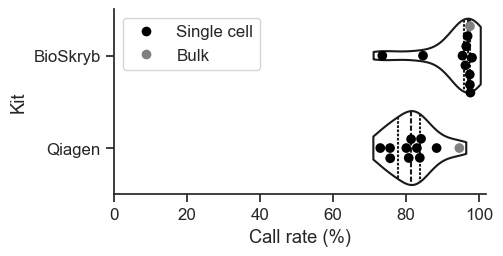

In [4]:
folder = Path("../data/ArrayGenotyping_snpseq01253/files/XK-4162_250519_ResultReport/XK-4162_250519_ResultReport_ICF_PLUS")
d = pd.read_csv(folder / "XK-4162_250519_GenotypingStatistics_ICF_PLUS.csv")
d["User ID"] = d["Individual"]
d = d.merge(samples, on="User ID")
d

fig, ax = plt.subplots(figsize=(4.8, 2.4))
ax = sns.swarmplot(d, x="Call rate per individual (%)", y="Kit", hue="Type", palette=["black", "grey"], edgecolor="k", s=7)
ax = sns.violinplot(d, x="Call rate per individual (%)", y="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_xlim(left=0)
ax.set_xlabel("Call rate (%)")
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.savefig(figdir / "array_call_rate.svg", dpi=300, bbox_inches="tight", transparent=True)

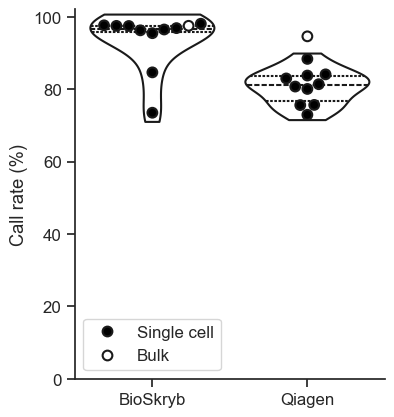

In [23]:
folder = Path("../data/ArrayGenotyping_snpseq01253/files/XK-4162_250519_ResultReport/XK-4162_250519_ResultReport_ICF_PLUS")
d = pd.read_csv(folder / "XK-4162_250519_GenotypingStatistics_ICF_PLUS.csv")
d["User ID"] = d["Individual"]
d = d.merge(samples, on="User ID")
d

fig, ax = plt.subplots(figsize=(4, 4.8))
ax = sns.swarmplot(d, y="Call rate per individual (%)", x="Kit", hue="Type", palette=["black", "white"], linewidth=1.5, edgecolor="k", s=7)
ax = sns.violinplot(d.query("Type == 'Single cell'"), y="Call rate per individual (%)", x="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_ylim(bottom=0)
ax.set_ylabel("Call rate (%)")
ax.set_xlabel("")
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.savefig(figdir / "array_call_rate_v.svg", dpi=300, bbox_inches="tight", transparent=True)

In [6]:
d.groupby(["Kit", "Type"])["Call rate per individual (%)"].agg(["median", "mean", "min", "max"])

median    mean    min    max
Kit      Type                                     
BioSkryb Bulk         97.500  97.500  97.50  97.50
         Single cell  96.670  93.381  73.49  98.07
Qiagen   Bulk         94.590  94.590  94.59  94.59
         Single cell  81.045  80.550  72.93  88.36

In [7]:
d[["SampleName", "Call rate per individual (%)"]].set_index("SampleName")\
    .style.background_gradient(axis=None, vmin=80, vmax=100, cmap="YlGnBu")

,Call rate per individual (%)
SampleName,
BioSkryb (Cell#03),97.450000
BioSkryb (Cell#04),95.460000
BioSkryb (Cell#05),97.480000
BioSkryb (Cell#01),98.070000
BioSkryb (Cell#02),96.860000
BioSkryb (Cell#06),96.250000
BioSkryb (Cell#07),73.490000
BioSkryb (Cell#08),84.640000
BioSkryb (Cell#09),97.630000


## Log-ratio for coverage evenness

https://www.illumina.com/Documents/products/technotes/technote_cytoanalysis.pdf

For each SNP is reported a log-ratio for the spot intensity values (log2(R_obs/R_exp)).

The mean of this log-ratio have been calculated in 100kb bins

In [8]:
def mad(x):
    # Median absolute deviation
    return np.abs(x - x.median()).median()

def mapd(data, cov_col="cov"):
    # Median absolute pairwise deviation
    dev = []

    # Find binsize
    binsize = data.iloc[0,:]["end"] - data.iloc[0,:]["start"]
    for c, cdata in data.groupby("contig"):
        x = cdata["cov"].values
        
        # Calculate deviation between adjacent bins
        deviation = x[:-1] - x[1:]

        # Find gaps
        gaps = (cdata["start"].values[1:] - cdata["start"].values[:-1]) > binsize
        # Remove gaps
        deviation = deviation[~gaps]
        dev.append(deviation)

    # Calculate median absolute pairwise deviation
    return np.median(np.abs(np.concatenate(dev)))


In [9]:
basedir = Path("../analysis/array_qc/bedgraph_100kb")
basedir2 = Path("../analysis/array_qc/bedgraph")
rdir = Path("../analysis/downsample_qc/downstream_qc/mosdepth_100kb")
assert basedir.exists()


cov = []
for file in basedir.rglob("*.bedgraph"):
    sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t", header=0, names=["contig", "start", "end", "cov"])
    d = d[d["contig"].isin(chr1toX) & (d["cov"] != ".")]
    d["cov"] = d["cov"].astype(float)

    # Reads coverage
    ngi_id = samples.query("`User ID` == @sample")["NGI ID"].values[0]
    rbedg = rdir / f"{ngi_id}.regions.bed.gz"
    d1 = pd.read_csv(rbedg, sep="\t", header=None, names=["contig", "start", "end", "cov"])
    d1 = d1[d1["contig"].isin(chr1toX)]
    d1["cov"] = np.log2(d1["cov"]/d1["cov"].median()) # Convert to log2 ratio
    d1 = d1[~np.isinf(d1["cov"])] # Remove inf values
    d1["cov"] = d1["cov"].astype(float)

    # Unbinned array coverage
    path = basedir2 / file.name 
    path = str(path).replace('LRR', 'LRR.sort')
    d2 = pd.read_csv(path, sep="\t", header=0, names=["contig", "start", "end", "cov"])
    d2 = d2[d2["contig"].isin(chr1toX) & (d2["cov"] != ".")]

    d2["cov"] = d2["cov"].astype(float)

    cov.append({
        "User ID": sample,
        "mad_arr": mad(d["cov"]),
        "mapd_arr": mapd(d),
        "mad_reads": mad(d1["cov"]),
        "mapd_reads": mapd(d1),
        "mad_arr_nobin": mad(d2["cov"]),
        "mapd_arr_nobin": mapd(d2),
    })


cov = pd.DataFrame(cov)
cov = cov.merge(samples, on="User ID")
cov = cov.sort_values("Kit", ascending=False)
cov

/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, me

,User ID,mad_arr,mapd_arr,mad_reads,mapd_reads,mad_arr_nobin,mapd_arr_nobin,NGI ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
11,Q_G2_cell_06,0.675677,0.540425,1.003652,0.992972,0.762658,0.169557,P33410_1006,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
1,Q_C3_cell_09,0.480937,0.427092,0.896194,0.811466,0.524278,0.126382,P33410_1010,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
18,Q_D2_cell_03,0.653875,0.589406,1.002952,1.008872,0.814145,0.167690,P33410_1003,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
17,Q_F2_cell_05,0.508517,0.517604,0.874270,0.944693,0.631998,0.164933,P33410_1005,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
16,Q_D3_cell_10,0.667192,0.610607,1.026839,1.071801,0.862517,0.155658,P33410_1011,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell
15,Q_B3_cell_08,0.340004,0.383020,0.686422,0.750069,0.406221,0.116171,P33410_1009,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
13,Q_A3_cell_07,0.483067,0.517110,0.824155,0.900938,0.563851,0.122426,P33410_1008,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
21,Q_H3_10_cells,0.153951,0.151704,0.396311,0.362661,0.219085,0.103600,P33410_1012,False,Qiagen,MM1S cell line,Human,Qiagen (Bulk),Bulk
6,Q_E2_cell_04,0.516858,0.554637,0.816389,0.923483,0.634942,0.148937,P33410_1004,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
5,Q_B2_cell_01,0.459554,0.499810,0.809629,0.897958,0.536609,0.123178,P33410_1001,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell


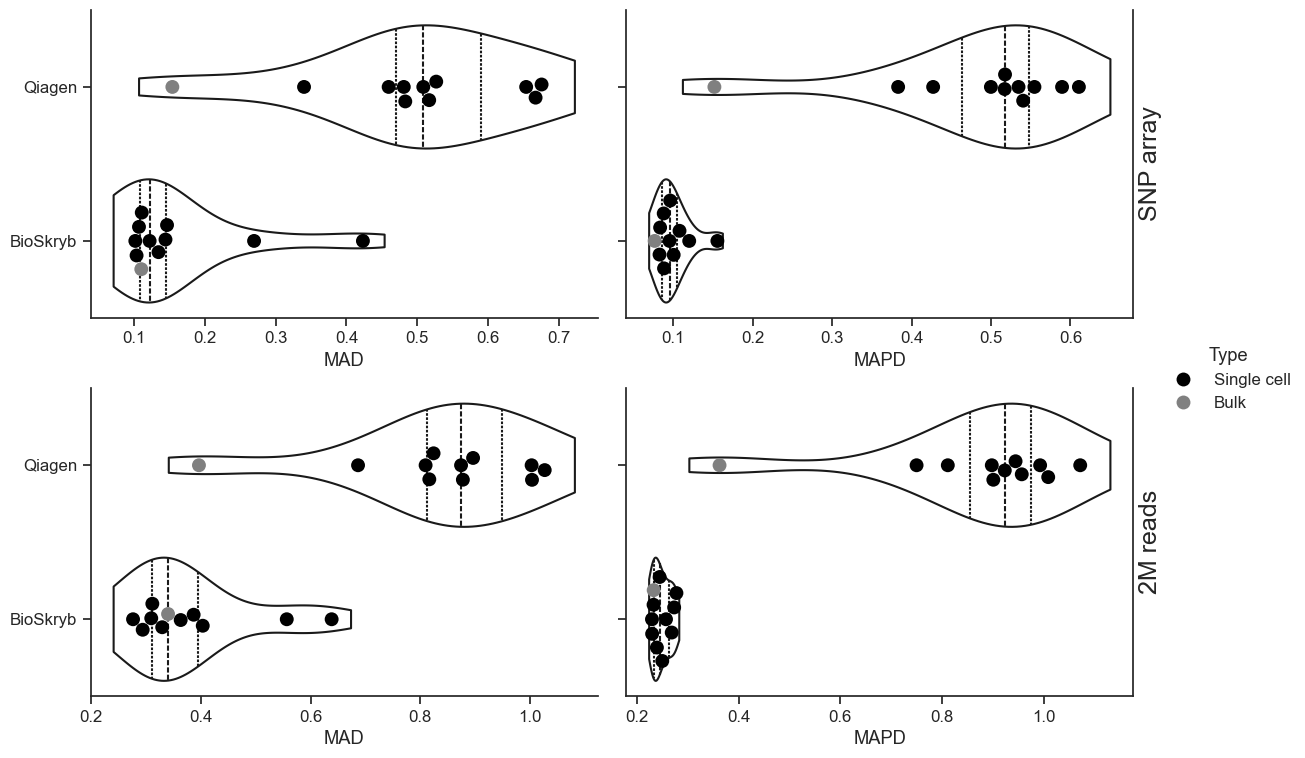

In [10]:
cols = [
    'mad_arr', 
    'mapd_arr', 
    'mad_reads', 
    'mapd_reads', 
    #'mad_arr_nobin', 
    #'mapd_arr_nobin'
]
d = cov.melt(
    id_vars=["Kit", "Type"], 
    value_vars=cols,
)

g = sns.catplot(d, kind="swarm", x="value", y="Kit", hue="Type", col="variable", 
            col_order=cols, palette=["black", "grey"],
            col_wrap=2, aspect=1.5, height=4, sharex=False, s=100)
g.map_dataframe(sns.violinplot, data=d.query("Type == 'Single cell'"), 
                x="value", y="Kit", inner="quart", fill=None, cut=0.5, 
                density_norm="width", color="k")
g.set_titles(template="")
g.set(ylabel="")
for s, ax in g.axes_dict.items():
    if ax.get_subplotspec().is_last_col():
        ax.set_xlabel("MAPD")

    if ax.get_subplotspec().is_first_col():
        ax.set_xlabel("MAD")
    
    if ax.get_subplotspec().is_last_col() and ax.get_subplotspec().is_first_row():
        ax2 = ax.secondary_yaxis(location="right") 
        ax2.set_yticks([])
        ax2.set_yticklabels([])
        ax2.set_ylabel("SNP array", fontsize=18)
    if ax.get_subplotspec().is_last_col() and ax.get_subplotspec().is_last_row():
        ax2 = ax.secondary_yaxis(location="right") 
        ax2.set_yticks([])
        ax2.set_yticklabels([])
        ax2.set_ylabel("2M reads", fontsize=18)
    



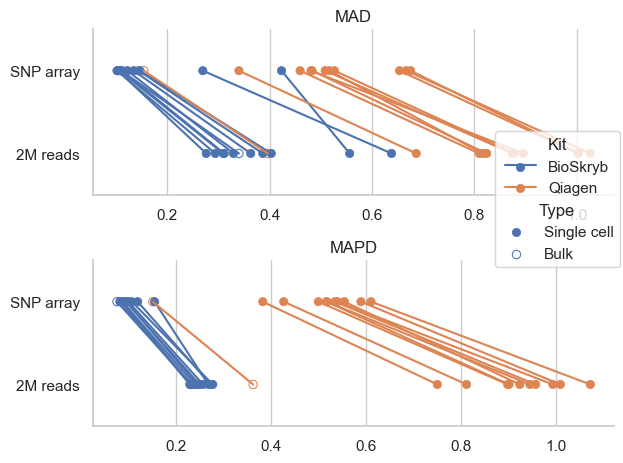

In [11]:
cols = [
    'mad_arr', 
    'mapd_arr', 
    'mad_reads', 
    'mapd_reads', 
    #'mad_arr_nobin', 
    #'mapd_arr_nobin'
]
d = cov.melt(
    id_vars=["Kit", "Type", "SampleName"], 
    value_vars=cols,
)
d = d.sort_values("SampleName", ascending=False)
d["ShortName"] = d["SampleName"].str[-4:-1]
d[["metric", "data"]] = d["variable"].str.split("_", expand=True)
d["data"] = d["data"].replace({
    "reads": "2M reads",
    "arr": "SNP array"
})

p = (
    so.Plot(d, y="data", x="value", color="Kit", group="SampleName")
    .facet(row="metric")
    .share(x=False)
    .add(so.Dot(), fill="Type")
    .add(so.Path())#, so.Dodge(by=["color"]), )
    .label(title=str.upper, y="", x="")
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .layout(engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .save(figdir / "array_mad_mapd_vs_2M_reads.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()

## Log-ratio vs 2M read coverage correlation

In [12]:
data = []
basedir = Path("../analysis/array_qc/bedgraph_100kb")
rdir = Path("../analysis/downsample_qc/downstream_qc/mosdepth_100kb")
assert basedir.exists()
assert rdir.exists()
for file in basedir.rglob("*.bedgraph"):
    sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t", header=None, names=["contig", "start", "end", "arr_logr"])
    d["User ID"] = sample
    ngi_id = samples.query("`User ID` == @sample")["NGI ID"].values[0]

    d = d[d["contig"].isin(chr1toX)]
    d["arr_logr"] = d["arr_logr"].replace({'.': np.nan})
    d["arr_logr"] = d["arr_logr"].astype(float)

    rbedg = rdir / f"{ngi_id}.regions.bed.gz"

    d2 = pd.read_csv(rbedg, sep="\t", header=None, names=["contig", "start", "end", "read_cov"])
    d = d.merge(d2, on=["contig", "start", "end"])
    d["read_logr"] = np.log2(d["read_cov"] / d["read_cov"].median()) 
    data.append(d)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="User ID")
data.head()


/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, me

,contig,start,end,arr_logr,User ID,read_cov,read_logr,NGI ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,chr1,0,100000,NaN,B_A4_cell_02,0.13410,-0.406134,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell
1,chr1,100000,200000,NaN,B_A4_cell_02,0.05670,-1.648023,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell
2,chr1,200000,300000,NaN,B_A4_cell_02,0.03936,-2.174642,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell
3,chr1,300000,400000,NaN,B_A4_cell_02,0.00298,-5.897988,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell
4,chr1,400000,500000,NaN,B_A4_cell_02,0.01208,-3.878751,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell


In [14]:

corrs = []

for s, d in data.groupby("SampleName"):
    d = d[(~d["arr_logr"].isna()) & (~d["read_logr"].isna()) & (~np.isinf(d["read_logr"]))]
    corr = spearmanr(d["arr_logr"], d["read_logr"]).correlation
    pcorr = pearsonr(d["arr_logr"], d["read_logr"])[0]
    corrs.append({
        "SampleName": s,
        "Spearman": corr,
        "Pearson": pcorr
    })

corrs = pd.DataFrame(corrs)
corrs = corrs.merge(samples, on="SampleName")
corrs[["SampleName", "Spearman", "Pearson"]].set_index("SampleName")\
    .style.background_gradient(axis=None, vmax=1,  vmin=0.7, cmap="YlGnBu").format(precision=2)


,Spearman,Pearson
SampleName,,
BioSkryb (Bulk),0.80,0.81
BioSkryb (Cell#01),0.79,0.80
BioSkryb (Cell#02),0.82,0.82
BioSkryb (Cell#03),0.77,0.79
BioSkryb (Cell#04),0.84,0.88
BioSkryb (Cell#05),0.73,0.77
BioSkryb (Cell#06),0.79,0.83
BioSkryb (Cell#07),0.91,0.96
BioSkryb (Cell#08),0.91,0.95


In [18]:
corrs["Spearman"].mean()

np.float64(0.8104994344960551)

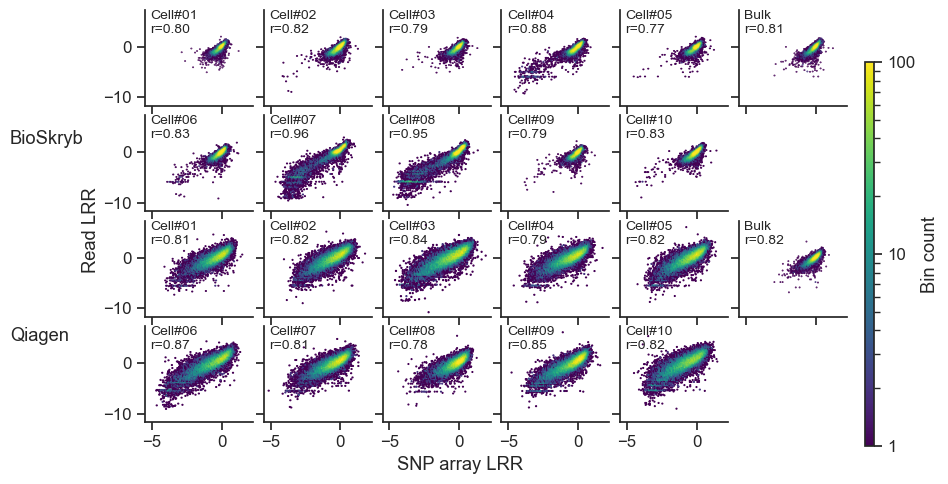

In [274]:

order = [
    'BioSkryb (Cell#01)',
    'BioSkryb (Cell#02)',
    'BioSkryb (Cell#03)',
    'BioSkryb (Cell#04)',
    'BioSkryb (Cell#05)',
    'BioSkryb (Bulk)',
    'BioSkryb (Cell#06)',
    'BioSkryb (Cell#07)',
    'BioSkryb (Cell#08)',
    'BioSkryb (Cell#09)',
    'BioSkryb (Cell#10)',
    None,
    'Qiagen (Cell#01)',
    'Qiagen (Cell#02)',
    'Qiagen (Cell#03)',
    'Qiagen (Cell#04)',
    'Qiagen (Cell#05)',
    'Qiagen (Bulk)',
    'Qiagen (Cell#06)',
    'Qiagen (Cell#07)',
    'Qiagen (Cell#08)',
    'Qiagen (Cell#09)',
    'Qiagen (Cell#10)',
    None
]

fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(9,4.8), sharex=True, sharey=True)

for ax, s in zip(axes.ravel(), order):
    if s is None:
        ax.axis("off")
        continue

    d = data.query("`SampleName` == @s")
    d = d[(~d["arr_logr"].isna()) & (~d["read_logr"].isna()) & (~np.isinf(d["read_logr"]))]
    #corr = spearmanr(d["arr_logr"], d["read_logr"]).correlation    
    corr = pearsonr(d["arr_logr"], d["read_logr"])[0]
    hb = ax.hexbin(d["arr_logr"], d["read_logr"], gridsize=100, cmap='viridis', bins='log', vmin=1, vmax=100, rasterized=True)
    
    name = s.split("(")[-1].split(")")[0]
    #ax.text(0.05, 1, f"{name}\nρ={corr:.2f}", transform=ax.transAxes, va="top", fontsize=10)
    ax.text(0.05, 1, f"{name}\nr={corr:.2f}", transform=ax.transAxes, va="top", fontsize=10)

fig.text(0.08, 0.5, "Read LRR", rotation=90, va="center")
fig.text(0.0, 0.68, "BioSkryb", ha="left")
fig.text(0.0, 0.27, "Qiagen", ha="left")
fig.text(0.5, 0, "SNP array LRR", ha="center")
plt.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1, left=0.15, right=0.93)
cbar_ax = fig.add_axes([0.95, 0.05, 0.01, 0.8])
fig.colorbar(hb, cax=cbar_ax, label="Bin count", ticks=[1, 10, 100])
cbar_ax.set_yticklabels(['1', '10', '100']) 
fig.savefig(figdir / "array_2M_reads_LRR_correlation.svg", dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(figdir / "array_2M_reads_LRR_correlation.pdf", dpi=300, bbox_inches="tight", transparent=True)


In [186]:
corrs["Correlation"].mean()

np.float64(0.8104994344960551)

Text(0.5, -0.7500000000000053, 'Spearmans r')

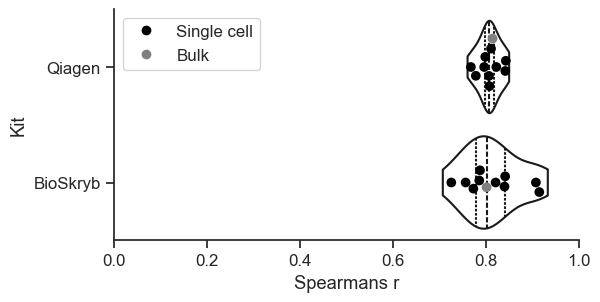

In [58]:
fig, ax = plt.subplots(figsize=(6, 3))
d = corrs.sort_values(by="Type", ascending=False)
ax = sns.swarmplot(d, x="Correlation", y="Kit", hue="Type", palette=["black", "grey"], edgecolor="k", s=7)
ax = sns.violinplot(d, x="Correlation", y="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_xlim(0, 1)
ax.set_xlabel("Spearmans r")


/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, me

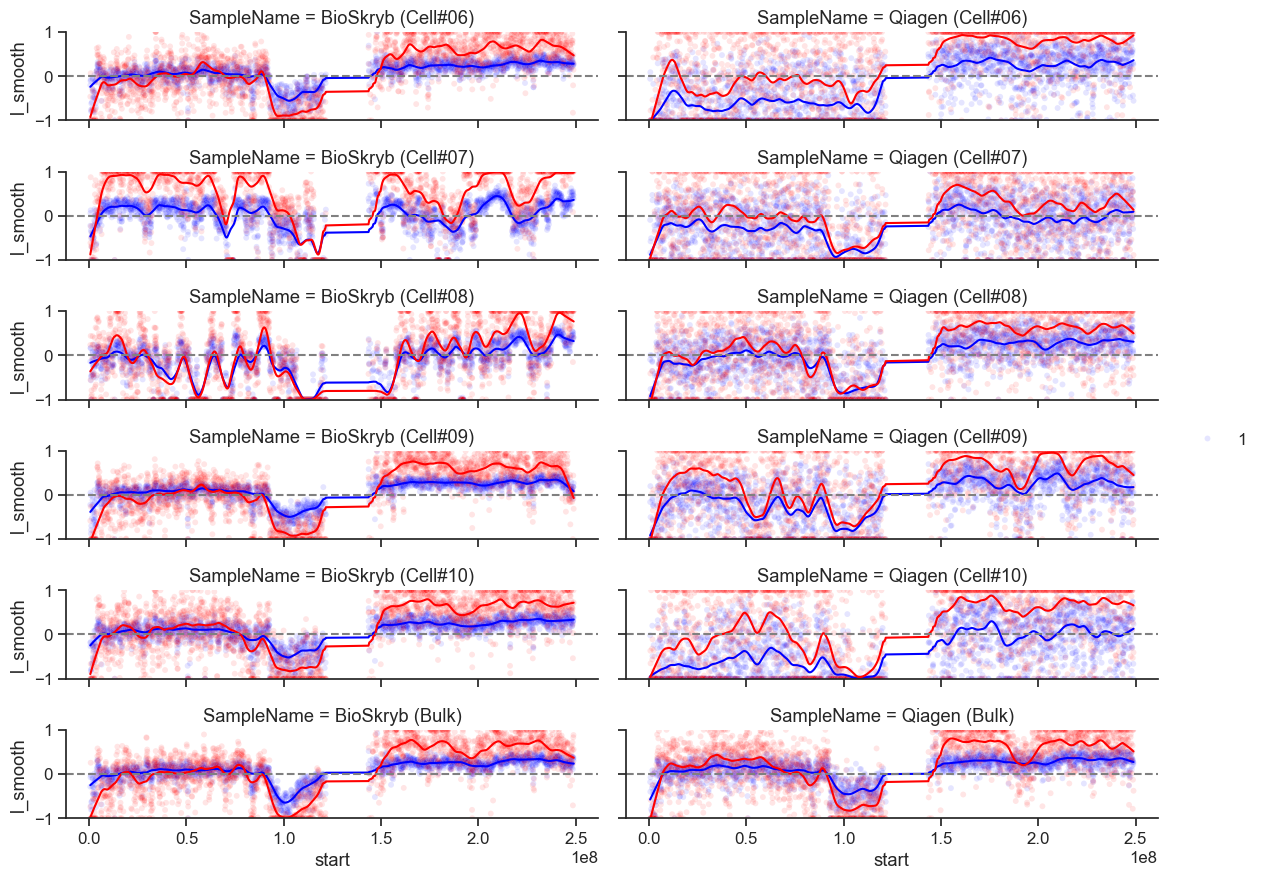

In [ ]:
import statsmodels.api as sm

def lowess(y, frac=0.05):
    x = np.linspace(0, 1, len(y))
    ysmooth = sm.nonparametric.lowess(y, x, frac=frac, missing="none")
    return ysmooth[:,1]

d = data.copy()

d["ncov"] = d.groupby("SampleName")["read_cov"].transform(lambda x: np.log2(x/x.median()))
d = d.query("contig == 'chr1'")


d["arr_logr"] = d["arr_logr"].clip(upper=1, lower=-1)
d["lread_co'v"] = d["read_logr"].clip(upper=1, lower=-1)

d["a_smooth"] = d.groupby("SampleName")["arr_logr"].transform(lowess)
d["l_smooth"] = d.groupby("SampleName")["read_logr"].transform(lowess)

kits = human_samples.groupby("Kit")["SampleName"].agg(list).tolist()
order = [s for l in zip(kits[0], kits[1]) for s in l]

g = sns.relplot(
    data=d,
    x="start",
    y="arr_logr",
    height=1.5,
    aspect=4,
    col="SampleName",
    col_wrap=2,
    color="blue",
    col_order=order[10:],
    size=1,
    alpha=0.1,
    facet_kws=dict(sharex=True)
)

g.map_dataframe(
    sns.scatterplot,
    data=d,
    x="start",
    y="read_logr",
    size=1,
    color="red",
    alpha=0.1,
)
g.map_dataframe(
    sns.lineplot,
    data=d,
    x="start",
    y="a_smooth",
    color="blue",
)

g.map_dataframe(
    sns.lineplot,
    data=d,
    x="start",
    y="l_smooth",
    color="red",
)

g.set(ylim=(-1, 1))
g.refline(y=0)

## SNP calls

In [208]:
basedir = Path("../analysis/array_qc")
snps = pd.read_csv(basedir / "samples.rename.gt.tsv.gz", sep="\t")

# Drop empty column
snps = snps.drop(columns=["Unnamed: 23"])

# Rename columns
cols = list(snps.columns)
cols = [c.split("]")[1].split(":")[0] for c in cols]
cols[0] = "loc"
snps.columns = cols
snsp = snps.set_index("loc")
snps.head()

,loc,B_A3_cell_01,B_A4_cell_02,B_B1_cell_03,B_B2_cell_04,B_B3_cell_05,B_B4_cell_06,B_C1_cell_07,B_C2_cell_08,B_C3_cell_09,...,Q_B2_cell_01,Q_B3_cell_08,Q_C2_cell_02,Q_C3_cell_09,Q_D2_cell_03,Q_D3_cell_10,Q_E2_cell_04,Q_F2_cell_05,Q_G2_cell_06,Q_H3_10_cells
0,1:632287,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
1,1:632828,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
2,1:633147,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
3,1:792461,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,./.,0/0,0/0,./.,0/0,0/0,0/0,0/0
4,1:817341,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,./.,0/0,./.,0/0,0/0,0/0,0/0,0/0


### Bulk comparison

Lets first check how the bulks compare

In [209]:
# Find positions where either bulk has call
no_call = ['./.', '.']
snpsb = snps.query("B_H3_10_cells not in @no_call or Q_H3_10_cells not in @no_call")

total_pos = snps.shape[0]
total = snpsb.shape[0]
match_bulk = snpsb.query("B_H3_10_cells == Q_H3_10_cells").shape[0]
mismatch_bulk = snpsb.query("B_H3_10_cells != Q_H3_10_cells").shape[0]

print(f"Bulk called positions: {total} ({total/total_pos:.2%}%)")
print(f"Matches: {match_bulk} ({match_bulk/total:.2%}%)")
print(f"Mismatches: {mismatch_bulk} ({mismatch_bulk/total:.2%}%)")


Bulk called positions: 638638 (98.72%%)
Matches: 602083 (94.28%%)
Mismatches: 36555 (5.72%%)


Most genotype match between the two bulk samples par ~5%, lets inspect the mismatches.

In [8]:
d = snpsb.query("B_H3_10_cells != Q_H3_10_cells")

b_no_call = d.query("B_H3_10_cells in @no_call").shape[0]
q_no_call = d.query("Q_H3_10_cells in @no_call").shape[0]

print(f"BioSkryb no call: {b_no_call} ({b_no_call/mismatch_bulk:.2%}%)")
print(f"Qiagen no call: {q_no_call} ({q_no_call/mismatch_bulk:.2%}%)")


BioSkryb no call: 7537 (20.62%%)
Qiagen no call: 26457 (72.38%%)


Majority of mismatches due to missing calls in Qiagen bulk

### Single cell comparison

#### Concordance with bulk called (either)
Look at how genotype compare to those called by either bulk

,SampleName,Kit,Type,n_missing,n_missing_pct
0,Qiagen (Cell#01),Qiagen,Single cell,97216,15.222395
1,Qiagen (Cell#02),Qiagen,Single cell,114691,17.958687
2,Qiagen (Cell#03),Qiagen,Single cell,151433,23.711868
3,Qiagen (Cell#04),Qiagen,Single cell,118873,18.613518
4,Qiagen (Cell#05),Qiagen,Single cell,123165,19.285573
5,Qiagen (Cell#06),Qiagen,Single cell,151199,23.675228
6,Qiagen (Cell#07),Qiagen,Single cell,104401,16.347446
7,Qiagen (Cell#08),Qiagen,Single cell,69510,10.884100
8,Qiagen (Cell#09),Qiagen,Single cell,99287,15.546679
9,Qiagen (Cell#10),Qiagen,Single cell,168919,26.449882


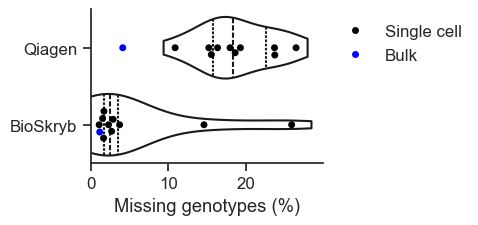

In [108]:
d = []
for _, sample in human_samples.iterrows():
    n_missing = snpsb.query(f"{sample['User ID']} in @no_call").shape[0]
    d.append({
        "SampleName": sample["SampleName"],
        "Kit": sample["Kit"],
        "Type": sample["Type"],
        "n_missing": n_missing,
        "n_missing_pct": 100 * n_missing / total
    })

d = pd.DataFrame(d)
display(d)

fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    d.query("Type == 'Single cell'"),
    x="n_missing_pct", 
    y="Kit",
    inner="quart", 
    fill=None, 
    legend=False,
    color="k",
    density_norm="width", 
    cut=0.5,
    ax=ax
)
ax = sns.swarmplot(d, x="n_missing_pct", y="Kit", hue="Type", palette=["black", "blue"], edgecolor="k",
)
ax.set_xlabel("Missing genotypes (%)")
ax.set_ylabel("")
ax.set_xlim(left=0)
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1,1))

#### Concordance with bulk called (both)
Compare how single cells compare to genotypes agreed upon by bulk.


,SampleName,Kit,Type,n_missing,n_missing_pct
0,Qiagen (Cell#01),Qiagen,Single cell,85065,13.319752
1,Qiagen (Cell#02),Qiagen,Single cell,101974,15.967418
2,Qiagen (Cell#03),Qiagen,Single cell,137308,21.500130
3,Qiagen (Cell#04),Qiagen,Single cell,106076,16.609723
4,Qiagen (Cell#05),Qiagen,Single cell,110071,17.235273
5,Qiagen (Cell#06),Qiagen,Single cell,136822,21.424031
6,Qiagen (Cell#07),Qiagen,Single cell,91947,14.397358
7,Qiagen (Cell#08),Qiagen,Single cell,57571,9.014653
8,Qiagen (Cell#09),Qiagen,Single cell,87083,13.635737
9,Qiagen (Cell#10),Qiagen,Single cell,154512,24.193988


/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_26313/3837713222.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1,1))


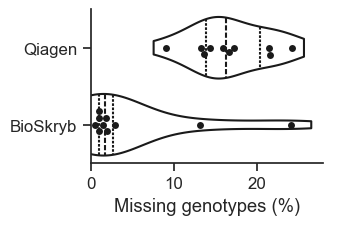

In [9]:
d = []
snpsbm = snpsb.query("B_H3_10_cells == Q_H3_10_cells").copy()
for _, sample in human_samples.iterrows():
    n_missing = snpsbm.query(f"{sample['User ID']} in @no_call").shape[0]
    d.append({
        "SampleName": sample["SampleName"],
        "Kit": sample["Kit"],
        "Type": sample["Type"],
        "n_missing": n_missing,
        "n_missing_pct": 100 * n_missing / total
    })

d = pd.DataFrame(d)
display(d)

fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    d.query("Type == 'Single cell'"),
    x="n_missing_pct", 
    y="Kit",
    inner="quart", 
    fill=None, 
    legend=False,
    color="k",
    density_norm="width", 
    cut=0.5,
    ax=ax
)
ax = sns.swarmplot(d.query("Type == 'Single cell'"), x="n_missing_pct", y="Kit", color="k")
ax.set_xlabel("Missing genotypes (%)")
ax.set_ylabel("")
ax.set_xlim(left=0)
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1,1))

Higher percentage missing in Qiagen samples as expected

#### Concordance with kit bulk sample - All genotypes

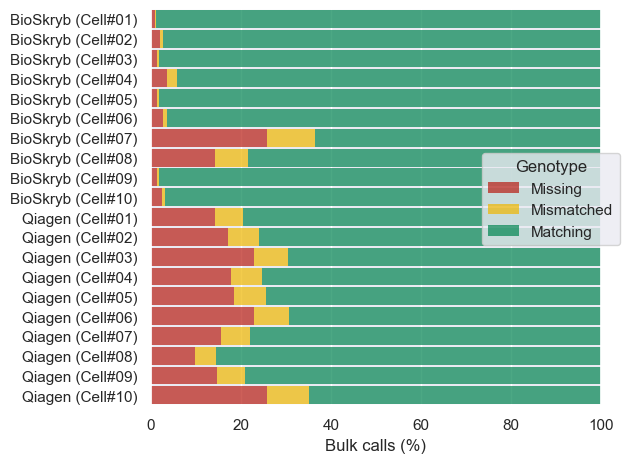

In [110]:
d = []
for kit, group in human_samples.groupby("Kit"):
    bulk_sample = group.query("IsSingleCell == False").iloc[0]
    sc_samples = group.query("IsSingleCell == True")
    
    snpsk = snps.query(f"{bulk_sample['User ID']} not in @no_call")

    for _, sample in sc_samples.iterrows():
        n_missing = snpsk.query(f"{sample['User ID']} in @no_call").shape[0]
        n_mismatch = snpsk.query(f"{sample['User ID']} != {bulk_sample['User ID']}").shape[0] - n_missing
        n_match = snpsk.query(f"{sample['User ID']} == {bulk_sample['User ID']}").shape[0]
    
        d.append({
            "SampleName": sample["SampleName"],
            "Kit": kit,
            "n_missing": n_missing,
            "n_missing_pct": 100 * n_missing / len(snpsk),
            "n_mismatch": n_mismatch,
            "n_mismatch_pct": 100 * n_mismatch / len(snpsk),
            "n_match": n_match,
            "n_match_pct": 100 * n_match / len(snpsk),
        })
        assert n_missing + n_match + n_mismatch == len(snpsk)

d = pd.DataFrame(d)
d = d.melt(id_vars=["SampleName", "Kit"], value_vars=["n_missing_pct", "n_mismatch_pct", "n_match_pct"], var_name="Genotype")

d["Genotype"] = d["Genotype"].replace(
    {
        "n_missing_pct": "Missing",
        "n_mismatch_pct": "Mismatched",
        "n_match_pct": "Matching"
    }
)
# Plot stacked bar chart
p = (
    so.Plot(d, y="SampleName", x="value", color="Genotype", group="Kit")
    .add(so.Bar(width=0.9, edgealpha=0), so.Agg(), so.Stack())
    .limit(x=(0,100))
    .label(
        x="Bulk calls (%)",
        y="",
    )
    .scale(color=["#B81D13", "#EFB700", "#008450"])
)
p.show()

#### Concordance with bulk consensus - All genotypes

602083


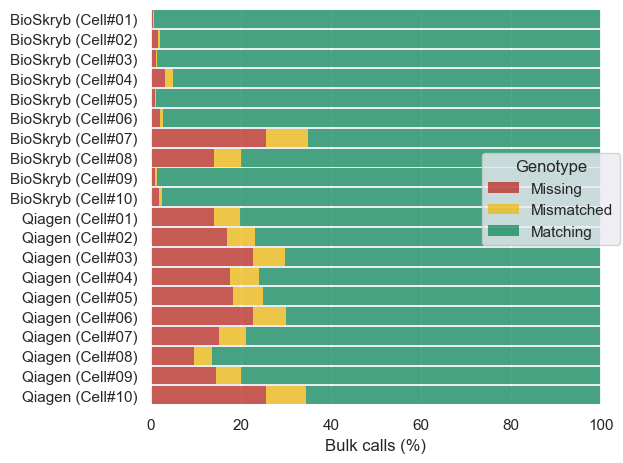

In [221]:
d = []
for kit, group in human_samples.groupby("Kit"):
    bulk_sample = group.query("IsSingleCell == False").iloc[0]
    sc_samples = group.query("IsSingleCell == True")
    
    for _, sample in sc_samples.iterrows():
        n_missing = snpsbm.query(f"{sample['User ID']} in @no_call").shape[0]
        n_mismatch = snpsbm.query(f"{sample['User ID']} != {bulk_sample['User ID']}").shape[0] - n_missing
        n_match = snpsbm.query(f"{sample['User ID']} == {bulk_sample['User ID']}").shape[0]
    
        d.append({
            "SampleName": sample["SampleName"],
            "Kit": kit,
            "n_missing": n_missing,
            "n_missing_pct": 100 * n_missing / len(snpsbm),
            "n_mismatch": n_mismatch,
            "n_mismatch_pct": 100 * n_mismatch / len(snpsbm),
            "n_match": n_match,
            "n_match_pct": 100 * n_match / len(snpsbm),
        })
        assert n_missing + n_match + n_mismatch == len(snpsbm)
print(len(snpsbm))
d = pd.DataFrame(d)
d = d.melt(id_vars=["SampleName", "Kit"], value_vars=["n_missing_pct", "n_mismatch_pct", "n_match_pct"], var_name="Genotype")

d["Genotype"] = d["Genotype"].replace(
    {
        "n_missing_pct": "Missing",
        "n_mismatch_pct": "Mismatched",
        "n_match_pct": "Matching"
    }
)
# Plot stacked bar chart
p = (
    so.Plot(d, y="SampleName", x="value", color="Genotype", group="Kit")
    .add(so.Bar(width=0.9, edgealpha=0), so.Agg(), so.Stack())
    .limit(x=(0,100))
    .label(
        x="Bulk calls (%)",
        y="",
    )
    .scale(color=["#B81D13", "#EFB700", "#008450"])
    .save(figdir / "array_bulk_consensus_genotype_concordance.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()

#### Concordance with kit bulk sample - Heterozygous only

Total heterozygous SNPs BioSkryb: 85254
Total heterozygous SNPs Qiagen: 69854


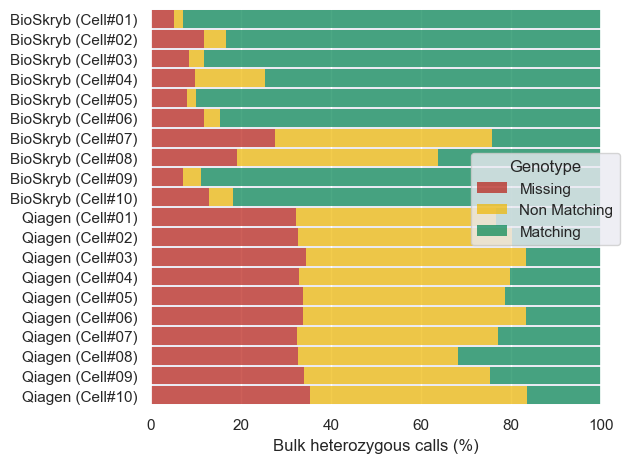

In [ ]:
d = []
for kit, group in human_samples.groupby("Kit"):
    bulk_sample = group.query("IsSingleCell == False").iloc[0]
    sc_samples = group.query("IsSingleCell == True")
    
    snpsk = snps.query(f"{bulk_sample['User ID']} not in @no_call")

    # only heterozygous
    hets = ["0/1", "0/2", "1/2"]
    snpsk = snpsk.query(f"{bulk_sample['User ID']} in @hets")
    print(f"Total heterozygous SNPs {kit}: {len(snpsk)}")
    for _, sample in sc_samples.iterrows():
        n_missing = snpsk.query(f"{sample['User ID']} in @no_call").shape[0]
        n_mismatch = snpsk.query(f"{sample['User ID']} != {bulk_sample['User ID']}").shape[0] - n_missing
        n_match = snpsk.query(f"{sample['User ID']} == {bulk_sample['User ID']}").shape[0]
    
        d.append({
            "SampleName": sample["SampleName"],
            "Kit": kit,
            "n_missing": n_missing,
            "n_missing_pct": 100 * n_missing / len(snpsk),
            "n_mismatch": n_mismatch,
            "n_mismatch_pct": 100 * n_mismatch / len(snpsk),
            "n_match": n_match,
            "n_match_pct": 100 * n_match / len(snpsk),
        })
        assert n_missing + n_match + n_mismatch == len(snpsk)

d = pd.DataFrame(d)
d = d.melt(id_vars=["SampleName", "Kit"], value_vars=["n_missing_pct", "n_mismatch_pct", "n_match_pct"], var_name="Genotype")

d["Genotype"] = d["Genotype"].replace(
    {
        "n_missing_pct": "Missing",
        "n_mismatch_pct": "Non Matching",
        "n_match_pct": "Matching"
    }
)
# Plot stacked bar chart
p = (
    so.Plot(d, y="SampleName", x="value", color="Genotype", group="Kit")
    .add(so.Bar(width=0.9, edgealpha=0), so.Agg(), so.Stack())
    .limit(x=(0,100))
    .scale(color=["#B81D13", "#EFB700", "#008450"]) 
    .label(
        x="Bulk heterozygous calls (%)",
        y="",
    )
)
p.show()

#### Concordance with bulk consensus - Heterozygous only

Total heterozygous SNPs BioSkryb: 64038
Total heterozygous SNPs Qiagen: 64038


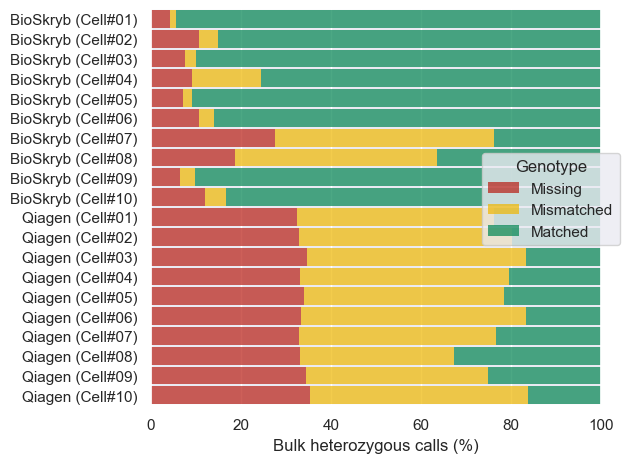

In [224]:
d = []
for kit, group in human_samples.groupby("Kit"):
    bulk_sample = group.query("IsSingleCell == False").iloc[0]
    sc_samples = group.query("IsSingleCell == True")
    
    snpsk = snps.query(f"{bulk_sample['User ID']} not in @no_call")

    # only heterozygous
    hets = ["0/1", "0/2", "1/2"]
    snpsk = snpsbm.query(f"{bulk_sample['User ID']} in @hets")
    print(f"Total heterozygous SNPs {kit}: {len(snpsk)}")
    for _, sample in sc_samples.iterrows():
        n_missing = snpsk.query(f"{sample['User ID']} in @no_call").shape[0]
        n_mismatch = snpsk.query(f"{sample['User ID']} != {bulk_sample['User ID']}").shape[0] - n_missing
        n_match = snpsk.query(f"{sample['User ID']} == {bulk_sample['User ID']}").shape[0]
    
        d.append({
            "SampleName": sample["SampleName"],
            "Kit": kit,
            "n_missing": n_missing,
            "n_missing_pct": 100 * n_missing / len(snpsk),
            "n_mismatch": n_mismatch,
            "n_mismatch_pct": 100 * n_mismatch / len(snpsk),
            "n_match": n_match,
            "n_match_pct": 100 * n_match / len(snpsk),
        })
        assert n_missing + n_match + n_mismatch == len(snpsk)

d = pd.DataFrame(d)
d = d.melt(id_vars=["SampleName", "Kit"], value_vars=["n_missing_pct", "n_mismatch_pct", "n_match_pct"], var_name="Genotype")

d["Genotype"] = d["Genotype"].replace(
    {
        "n_missing_pct": "Missing",
        "n_mismatch_pct": "Mismatched",
        "n_match_pct": "Matched"
    }
)
# Plot stacked bar chart
p = (
    so.Plot(d, y="SampleName", x="value", color="Genotype", group="Kit")
    .add(so.Bar(width=0.9, edgealpha=0), so.Agg(), so.Stack())
    .limit(x=(0,100))
    .scale(color=["#B81D13", "#EFB700", "#008450"]) 
    .label(
        x="Bulk heterozygous calls (%)",
        y="",
    )
    .save(figdir / "array_bulk_consensus_genotype_concordance_hets.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()

#### Genomic distribution

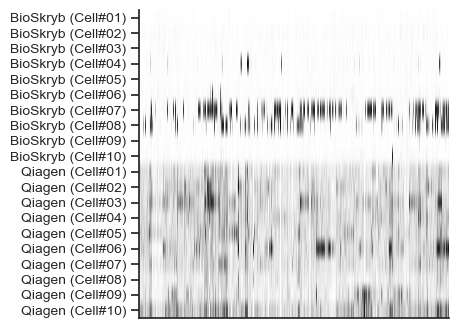

In [131]:
d = ~snpsbm.set_index("loc").isin(no_call).astype(int)
hs = human_samples.query("Type == 'Single cell'")
hs = hs.sort_values(["Kit", "SampleName"])
d = d[hs["User ID"]]
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(d.values.T, cmap="gray", aspect="auto")
ax.set_yticks(range(0, d.shape[1]))
# Remove xticks
ax.set_xticks([])
ax.set_xticklabels([])
_ = ax.set_yticklabels(hs["SampleName"], fontsize=10)

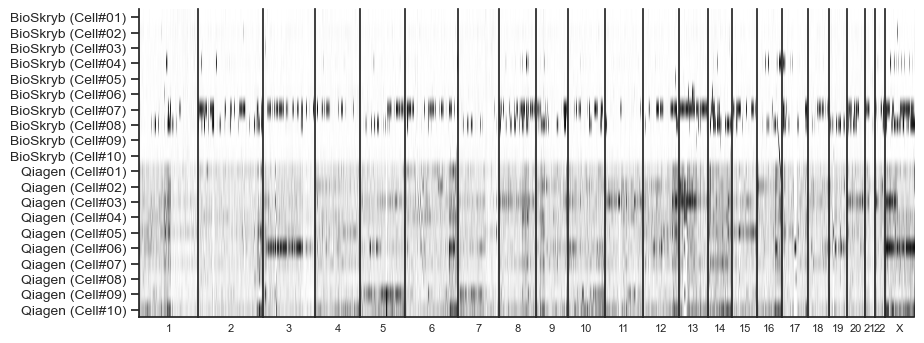

In [39]:
d = ~snpsbm.set_index("loc").isin(no_call).astype(int)
d = d.reset_index(
)
d["chrom"] = d["loc"].str.split(":", expand=True)[0]
d["pos"] = d["loc"].str.split(":", expand=True)[1]
chr_lens = d.groupby("chrom")["pos"].count().to_dict()

hs = human_samples.query("Type == 'Single cell'")
hs = hs.sort_values(["Kit", "SampleName"])

ratios = [chr_lens[chrom] for chrom in chr1toXhs]
ratios = [l/sum(ratios) for l in ratios]
fig, axes = plt.subplots(
    ncols=len(chr1toXhs), 
    figsize=(10,4), 
    width_ratios=ratios,
    
)
for ax, chrom in zip(axes.ravel(), chr1toXhs):
    dchrom = d.query("chrom == @chrom").copy()
    dchrom = dchrom.drop(columns=["chrom", "pos"])
    dchrom = dchrom.set_index("loc")
    dchrom = dchrom[hs["User ID"]]
    ax.imshow(dchrom.values.T, cmap="gray", aspect="auto")
    
    if chrom == "1":
        ax.set_yticks(range(0, dchrom.shape[1]))
        _ = ax.set_yticklabels(hs["SampleName"], fontsize=10)
    else:
        ax.set_yticks([])
    # Remove xticks
    ax.set_xticks([])
    ax.set_xticklabels([])
    
    ax.set_xlabel(chrom, fontsize=8)

fig.subplots_adjust(wspace=0)

,B_A3_cell_01,B_A4_cell_02,B_B1_cell_03,B_B2_cell_04,B_B3_cell_05,B_B4_cell_06,B_C1_cell_07,B_C2_cell_08,B_C3_cell_09,B_C4_cell_10,...,Q_B2_cell_01,Q_B3_cell_08,Q_C2_cell_02,Q_C3_cell_09,Q_D2_cell_03,Q_D3_cell_10,Q_E2_cell_04,Q_F2_cell_05,Q_G2_cell_06,Q_H3_10_cells
loc,,,,,,,,,,,,,,,,,,,,,
1:632287,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1:632828,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1:633147,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1:792461,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
1:817341,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
X:156000685,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,1,0
X:156000700,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,1,0
X:156001059,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,1,0


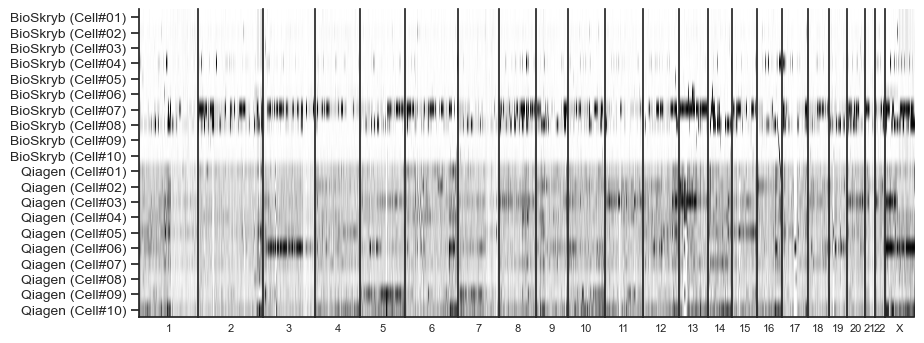

In [46]:
d = snpsbm.set_index("loc").copy()
d = d.apply(lambda x: x == d["Q_H3_10_cells"]).astype(int)
d = d.reset_index()
d["chrom"] = d["loc"].str.split(":", expand=True)[0]
d["pos"] = d["loc"].str.split(":", expand=True)[1]
chr_lens = d.groupby("chrom")["pos"].count().to_dict()

hs = human_samples.query("Type == 'Single cell'")
hs = hs.sort_values(["Kit", "SampleName"])

ratios = [chr_lens[chrom] for chrom in chr1toXhs]
ratios = [l/sum(ratios) for l in ratios]
fig, axes = plt.subplots(
    ncols=len(chr1toXhs), 
    figsize=(10,4), 
    width_ratios=ratios,
    
)
for ax, chrom in zip(axes.ravel(), chr1toXhs):
    dchrom = d.query("chrom == @chrom").copy()
    dchrom = dchrom.drop(columns=["chrom", "pos"])
    dchrom = dchrom.set_index("loc")
    dchrom = dchrom[hs["User ID"]]
    ax.imshow(dchrom.values.T, cmap="gray", aspect="auto")
    
    if chrom == "1":
        ax.set_yticks(range(0, dchrom.shape[1]))
        _ = ax.set_yticklabels(hs["SampleName"], fontsize=10)
    else:
        ax.set_yticks([])
    # Remove xticks
    ax.set_xticks([])
    ax.set_xticklabels([])
    
    ax.set_xlabel(chrom, fontsize=8)

fig.subplots_adjust(wspace=0)

In [214]:
d = ~snpsbm.set_index("loc").isin(no_call).astype(int)
hs = human_samples.query("Type == 'Single cell'")
hs = hs.sort_values(["Kit", "SampleName"])
d = d[hs["User ID"]]
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(d.values.T, cmap="gray", aspect="auto")
ax.set_yticks(range(0, d.shape[1]))
# Remove xticks
ax.set_xticks([])
ax.set_xticklabels([])
_ = ax.set_yticklabels(hs["SampleName"], fontsize=10)

NameError: name 'snpsbm' is not defined

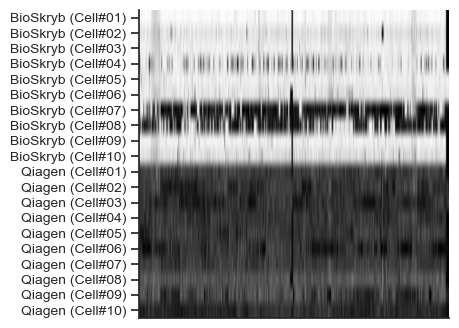

In [134]:
d = snpsbm.set_index("loc").query("Q_H3_10_cells in @hets and B_H3_10_cells in @hets").copy()
d = d.isin(hets).astype(int)
d = d[hs["User ID"]]
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(d.values.T, cmap="gray", aspect="auto")
ax.set_yticks(range(0, d.shape[1]))
ax.set_xticks([])
ax.set_xticklabels([])
_ = ax.set_yticklabels(hs["SampleName"], fontsize=10)

### AF / LRR 

In [212]:
basedir = Path("../analysis/array_qc")
vcf = pd.read_csv(basedir / "samples.rename.vcf.gz", sep="\t", skiprows=37, header=0, nrows=100000)
vcf["chrom_pos_id"] = vcf[["#CHROM", "POS", "ID"]].agg(lambda x: "_".join(map(str,x)), axis=1)
vcf = vcf.melt(
    id_vars=["chrom_pos_id"],
    value_vars=human_samples["User ID"].values,
    value_name="GT:GS:BAF:LRR",
    var_name="User ID"
)
vcf["GT:GS:BAF:LRR".split(":")] = vcf["GT:GS:BAF:LRR"].str.split(":",expand=True)
vcf = vcf.drop(columns=["GT:GS:BAF:LRR"])
vcf = vcf.pivot(index=["chrom_pos_id"], columns="User ID", values=["GT", "GS", "BAF", "LRR"])

bulk_samples = ["B_H3_10_cells", "Q_H3_10_cells"]
gt_matching = vcf[("GT", bulk_samples[0])] == vcf[("GT", bulk_samples[1])]
gt_call = ~vcf[("GT", bulk_samples[0])].isin(no_call)

# Get bulk matching and called postions
vcf = vcf[gt_matching & gt_call]
for sample in human_samples["User ID"].to_list():
    vcf[("Match", sample)] = vcf[("GT", bulk_samples[0])] == vcf[("GT", sample)]
    vcf[("Missing", sample)] = vcf[("GT", sample)].isin(no_call)

vcf = vcf.unstack(level=1).reset_index().pivot(index=["chrom_pos_id", "User ID"], columns="level_0", values=0).reset_index()
vcf = vcf.query('BAF != "."')
vcf["BAF"] = vcf["BAF"].astype(float)
vcf["LRR"] = vcf["LRR"].astype(float)
vcf["GS"] = vcf["GS"].astype(float)
vcf["Match"] = vcf["Match"].astype(bool)
vcf["Missing"] = vcf["Missing"].astype(bool)
vcf




level_0,chrom_pos_id,User ID,BAF,GS,GT,LRR,Match,Missing
0,10_100005233_GSA-rs77707291,B_A3_cell_01,0.000000,0.7448,0/0,-0.032986,True,False
1,10_100005233_GSA-rs77707291,B_A4_cell_02,0.015173,0.7448,0/0,-0.321547,True,False
2,10_100005233_GSA-rs77707291,B_B1_cell_03,0.000000,0.7448,0/0,0.099503,True,False
3,10_100005233_GSA-rs77707291,B_B2_cell_04,0.007805,0.7448,0/0,-0.097377,True,False
4,10_100005233_GSA-rs77707291,B_B3_cell_05,0.000000,0.7448,0/0,-0.000709,True,False
...,...,...,...,...,...,...,...,...
2066719,1_99993238_GSA-rs72728114,Q_D3_cell_10,0.641049,0.0972,./.,-2.937370,False,True
2066720,1_99993238_GSA-rs72728114,Q_E2_cell_04,0.000000,0.7453,0/0,0.607095,True,False
2066721,1_99993238_GSA-rs72728114,Q_F2_cell_05,1.000000,0.0543,./.,-3.966230,False,True
2066722,1_99993238_GSA-rs72728114,Q_G2_cell_06,0.000000,0.7453,0/0,0.355195,True,False


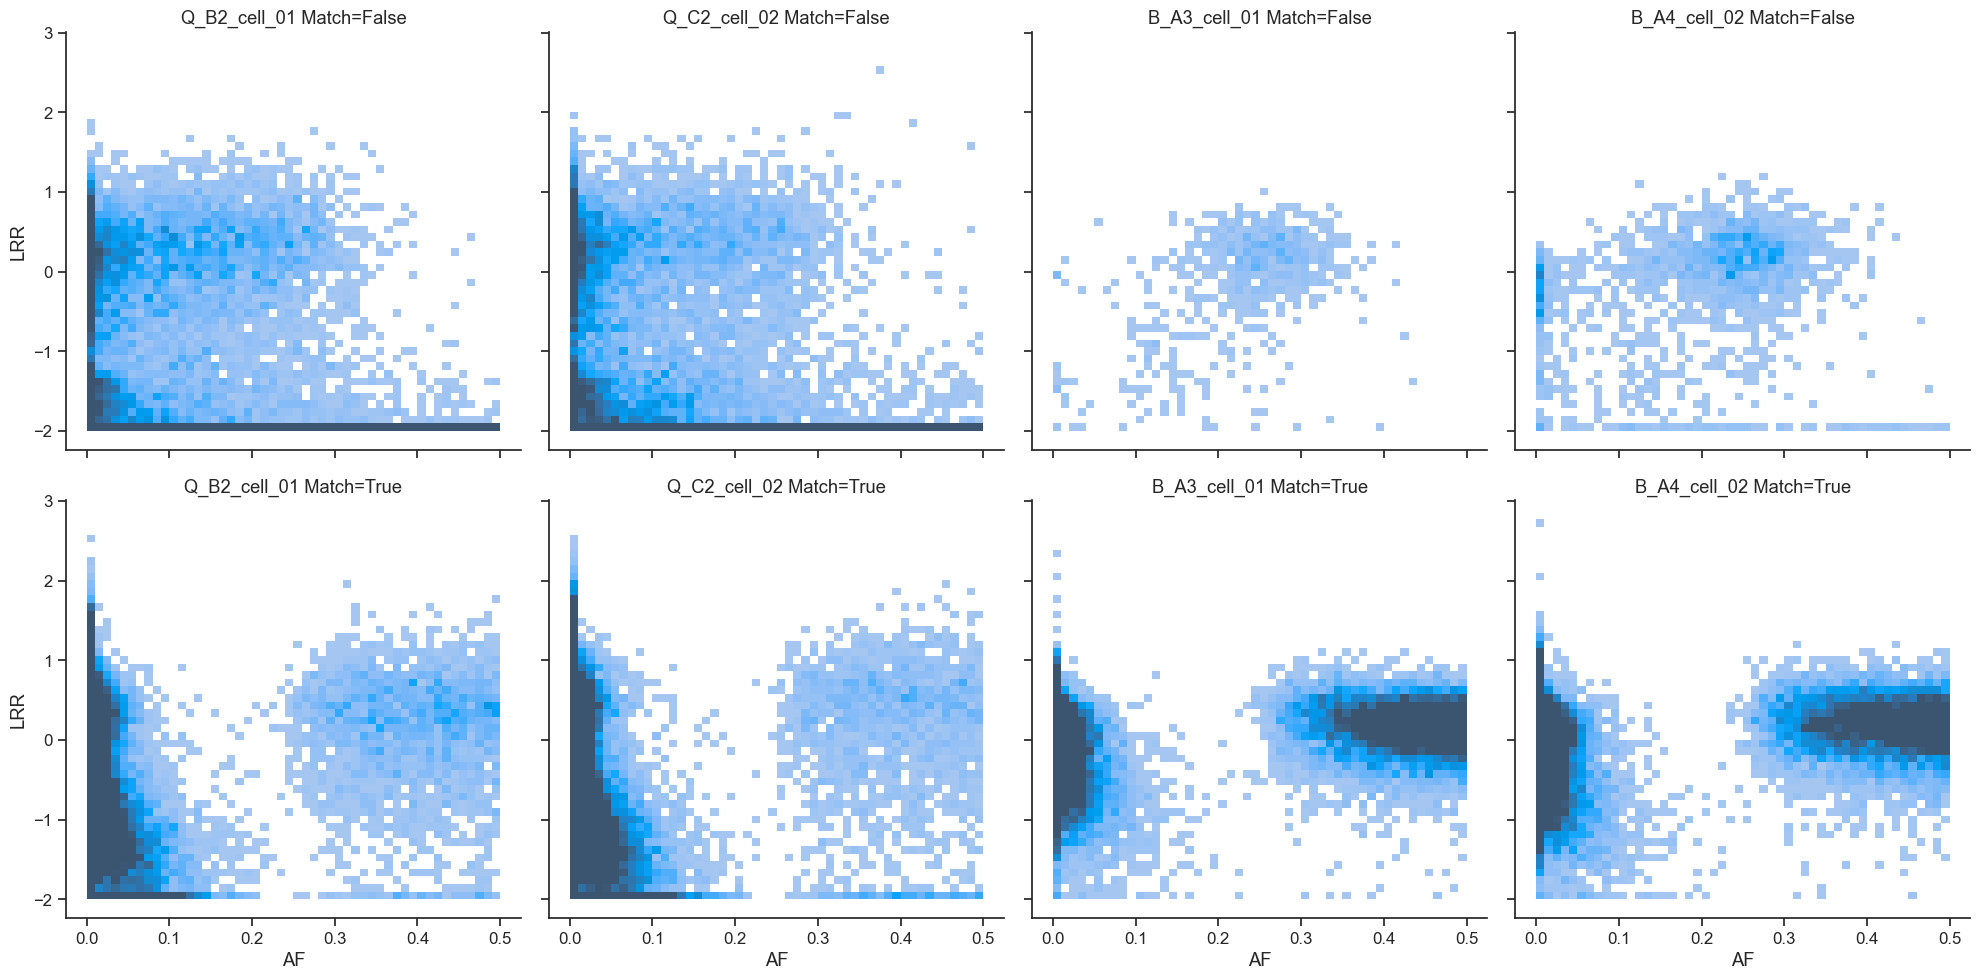

In [241]:
hs = human_samples.query("Type == 'Single cell'")
d = vcf.copy()
order = ["Q_B2_cell_01", "Q_C2_cell_02", "B_A3_cell_01", "B_A4_cell_02"]
d = d[d["User ID"].isin(order)]
d["LRR"] = d["LRR"].apply(lambda x: max(x, -2))
d["AF"] = d["BAF"].apply(lambda x: min(x, 1-x))
g = sns.displot(d, kind="hist", x="AF", y="LRR", col="User ID", row="Match", bins=50, pmax=0.1,col_order=order)
g.set_titles("{col_name} Match={row_name}")

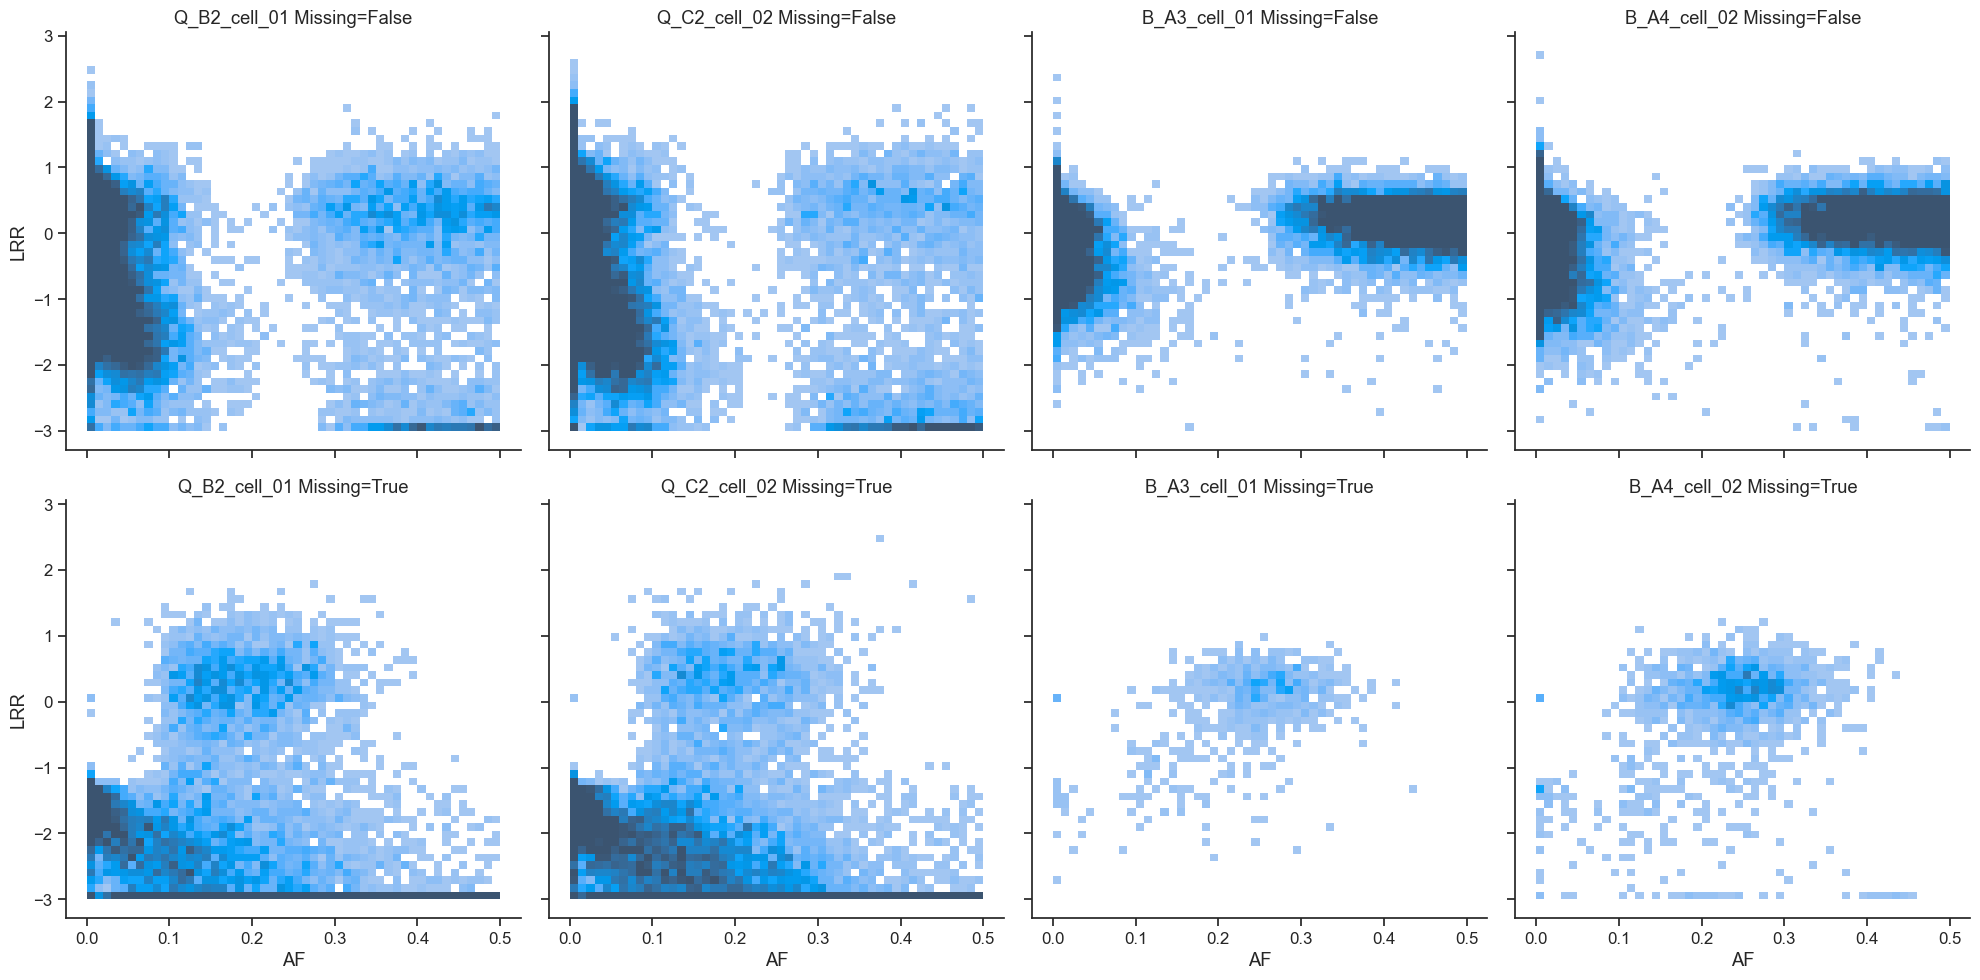

In [283]:
hs = human_samples.query("Type == 'Single cell'")
d = vcf.copy()
order = ["Q_B2_cell_01", "Q_C2_cell_02", "B_A3_cell_01", "B_A4_cell_02"]
d = d[d["User ID"].isin(order)]
d["LRR"] = d["LRR"].apply(lambda x: max(x, -3))
d["AF"] = d["BAF"].apply(lambda x: min(x, 1-x))
g = sns.displot(d, kind="hist", x="AF", y="LRR", col="User ID", row="Missing", bins=50, pmax=0.1, col_order=order)
g.set_titles("{col_name} Missing={row_name}")

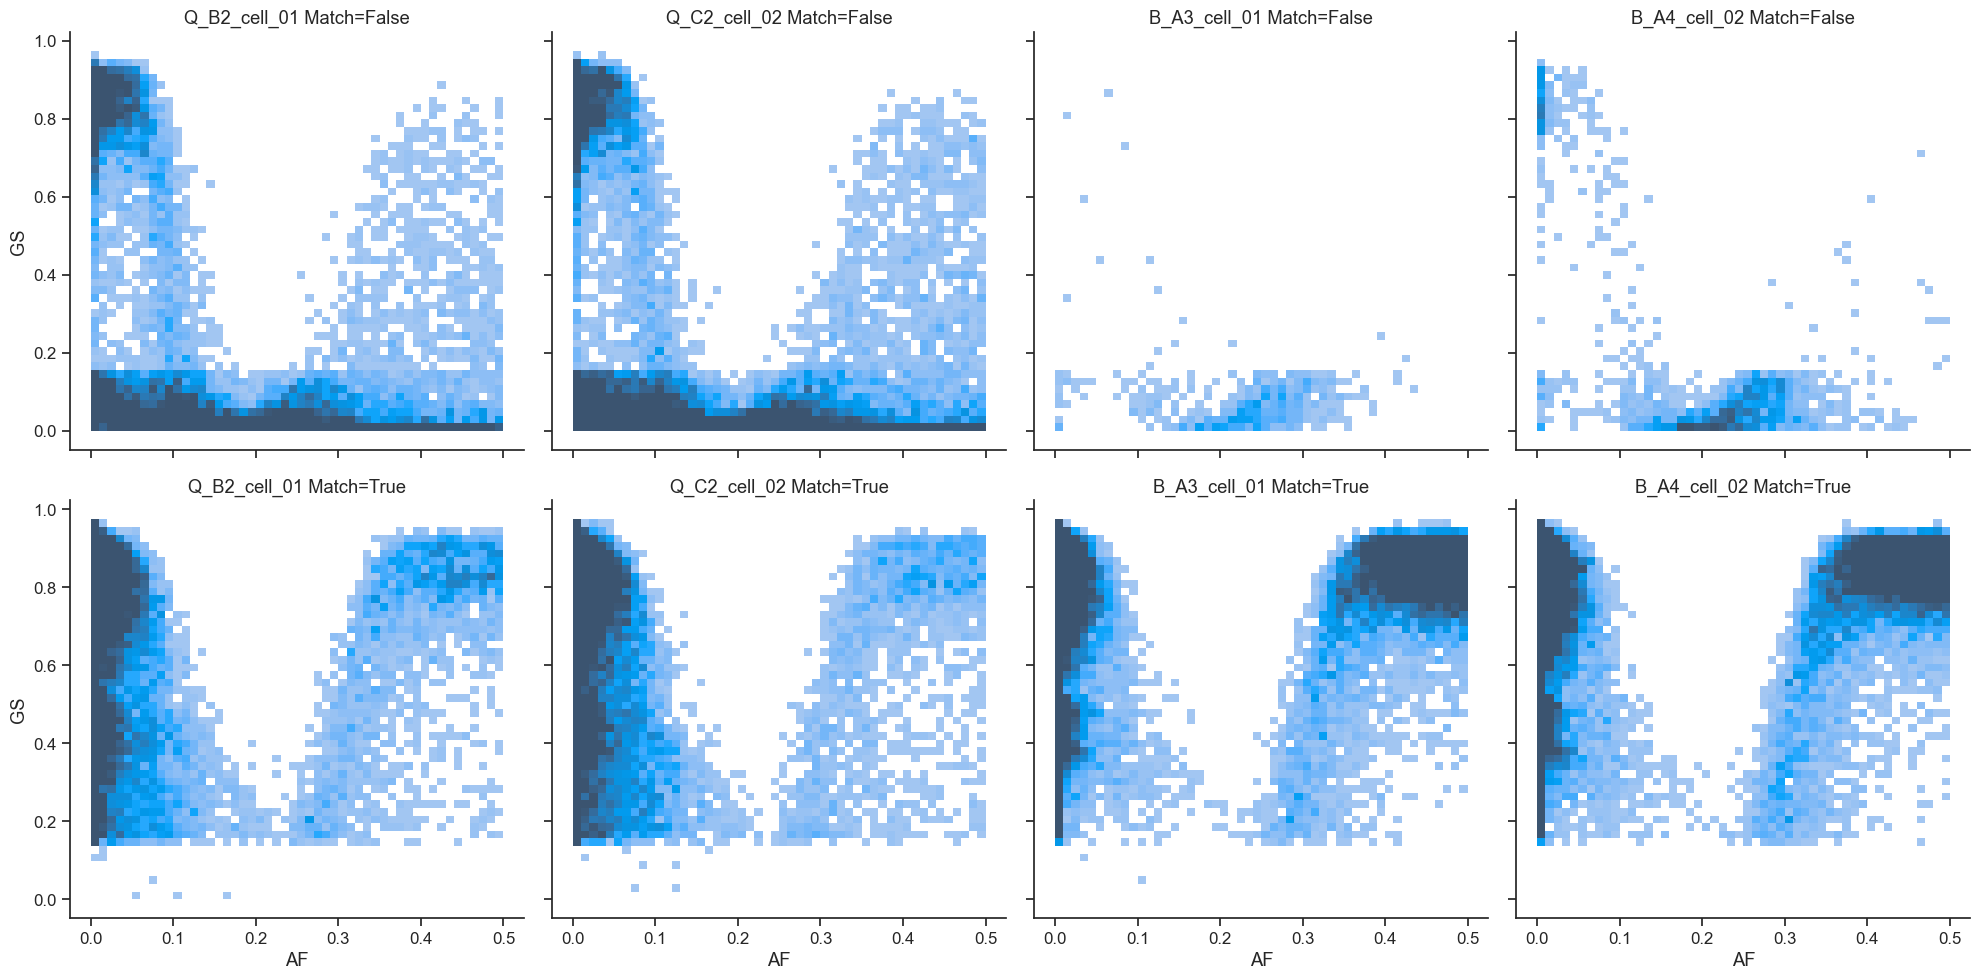

In [285]:
hs = human_samples.query("Type == 'Single cell'")
d = vcf.copy()
order = ["Q_B2_cell_01", "Q_C2_cell_02", "B_A3_cell_01", "B_A4_cell_02"]
d = d[d["User ID"].isin(order)]
d["LRR"] = d["LRR"].apply(lambda x: max(x, -3))
d["AF"] = d["BAF"].apply(lambda x: min(x, 1-x))
g = sns.displot(d, kind="hist", x="AF", y="GS", col="User ID", row="Match", bins=50, pmax=0.1, col_order=order)
g.set_titles("{col_name} Match={row_name}")

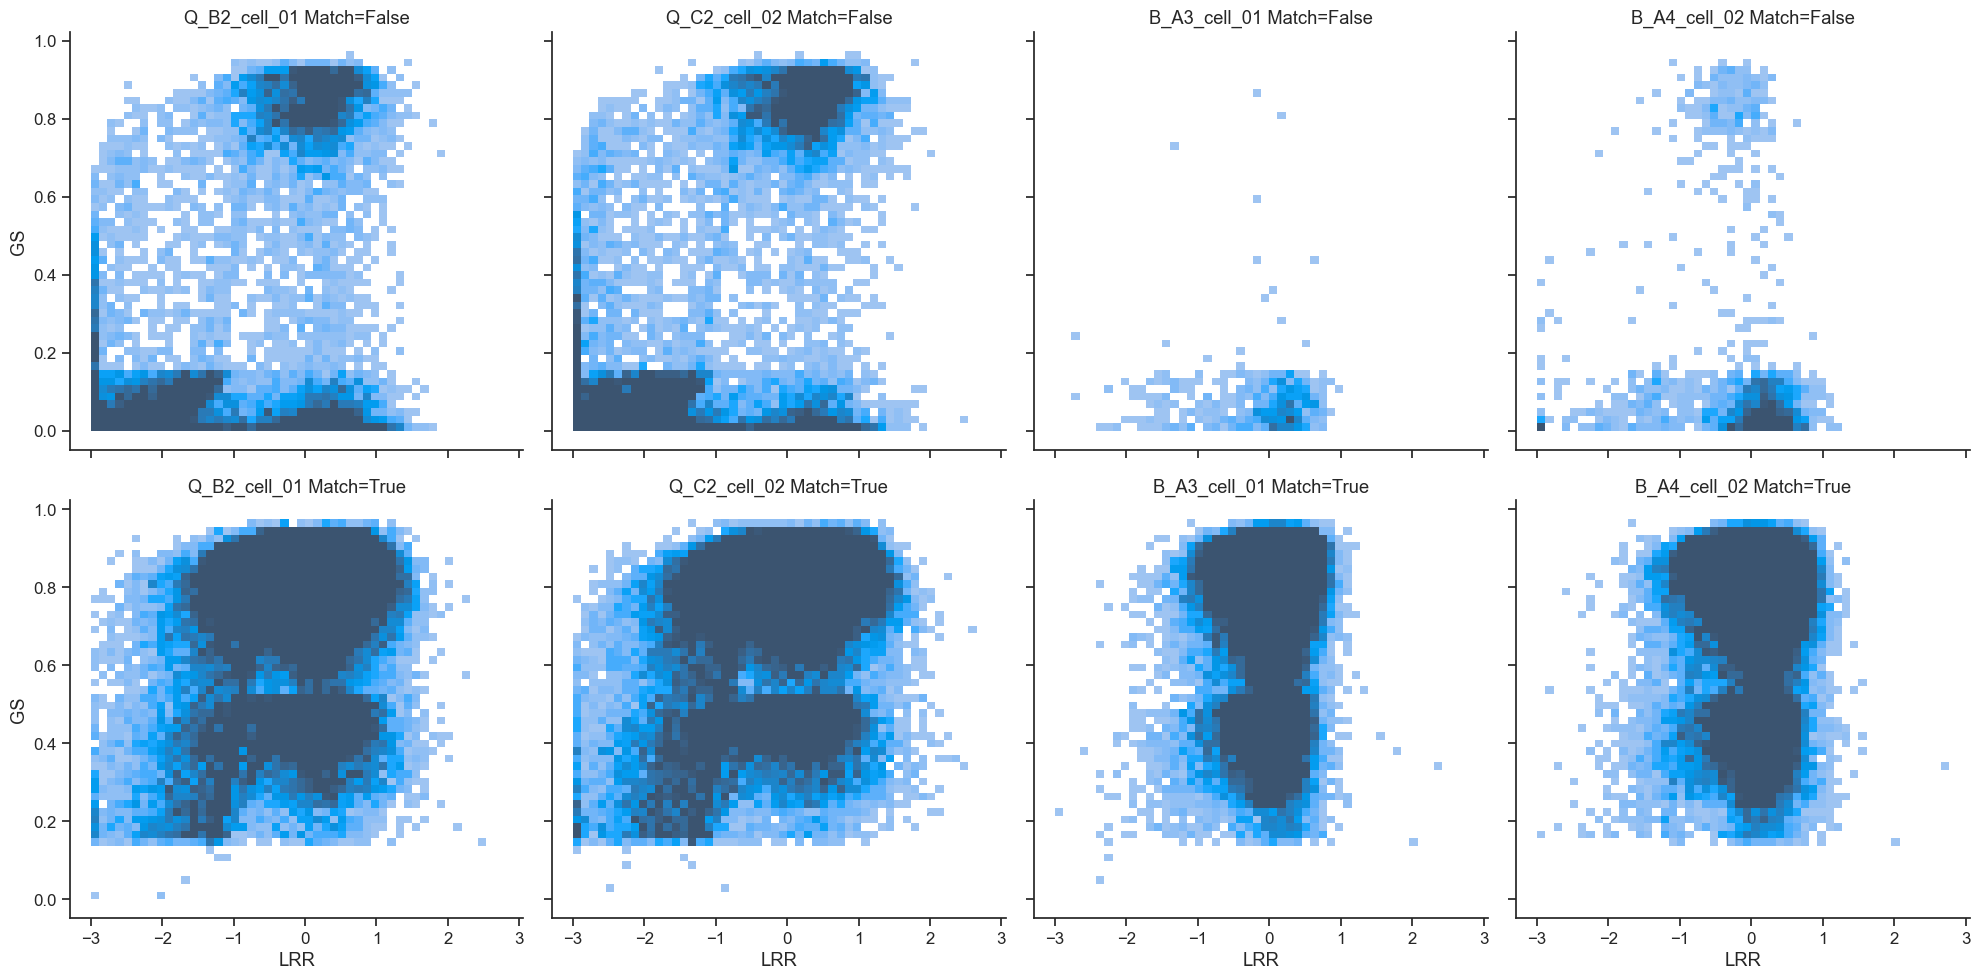

In [286]:
hs = human_samples.query("Type == 'Single cell'")
d = vcf.copy()
order = ["Q_B2_cell_01", "Q_C2_cell_02", "B_A3_cell_01", "B_A4_cell_02"]
d = d[d["User ID"].isin(order)]
d["LRR"] = d["LRR"].apply(lambda x: max(x, -3))
d["AF"] = d["BAF"].apply(lambda x: min(x, 1-x))
g = sns.displot(d, kind="hist", x="LRR", y="GS", col="User ID", row="Match", bins=50, pmax=0.1, col_order=order)
g.set_titles("{col_name} Match={row_name}")

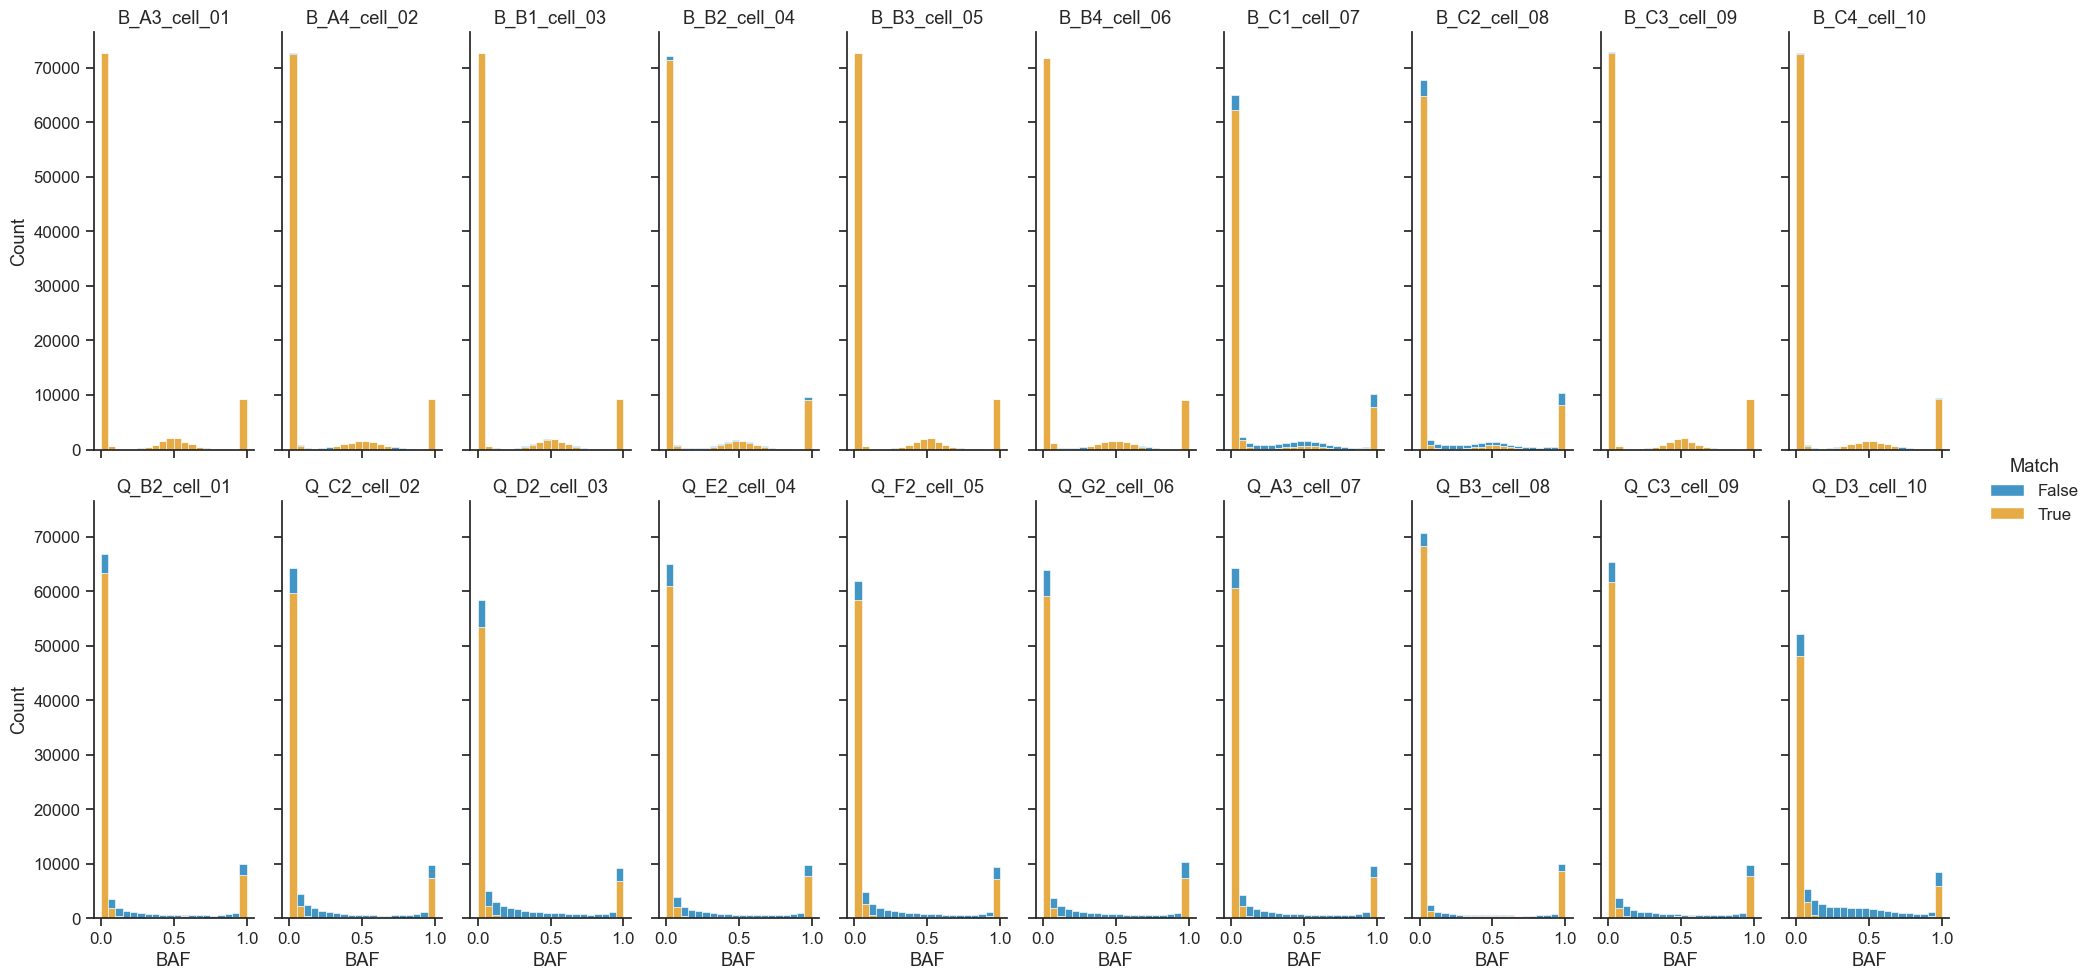

In [217]:
g = sns.displot(vcf, kind="hist", x="BAF", hue="Match", col="User ID", col_wrap=10, multiple="stack", bins=20, col_order=hs["User ID"], aspect=0.4)
g.set_titles("{col_name}")

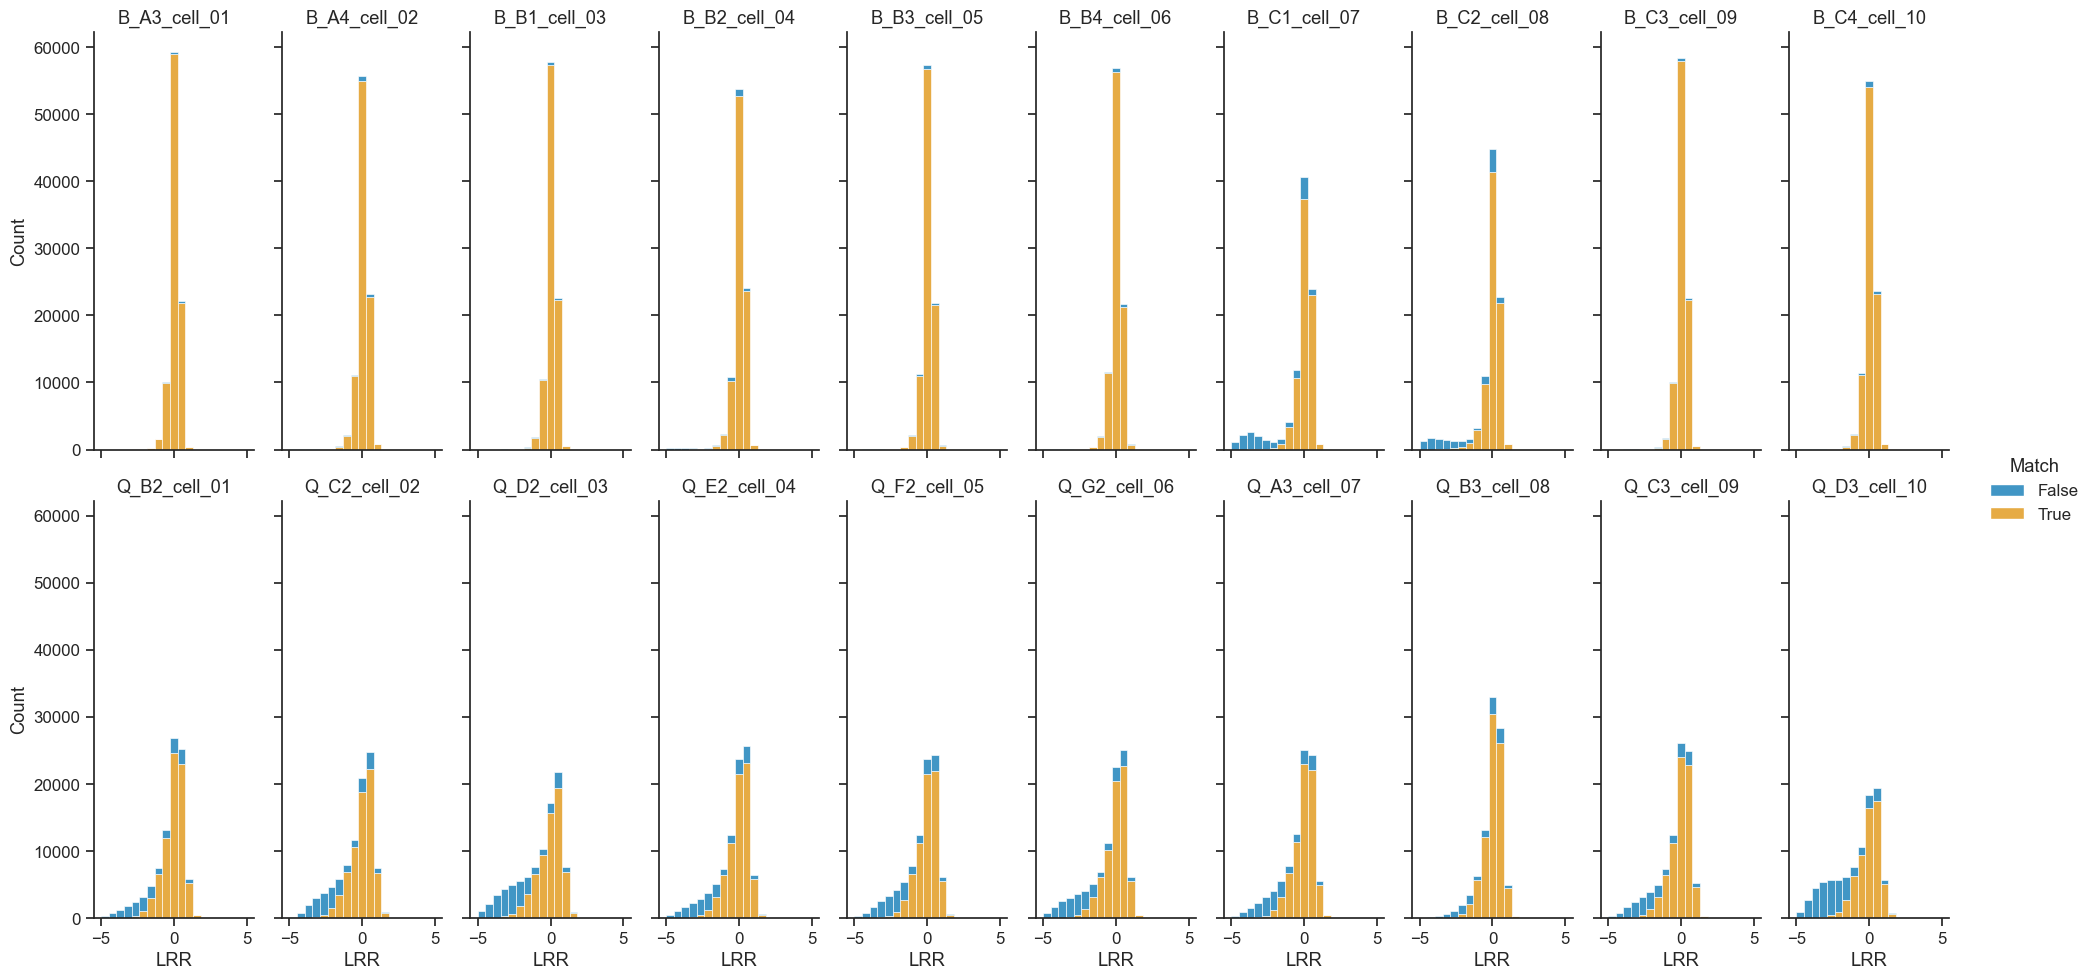

In [219]:
g = sns.displot(vcf, kind="hist", x="LRR", hue="Match", col="User ID", col_wrap=10, multiple="stack", bins=np.linspace(-5,5, 20), col_order=hs["User ID"], aspect=0.4)
g.set_titles("{col_name}")

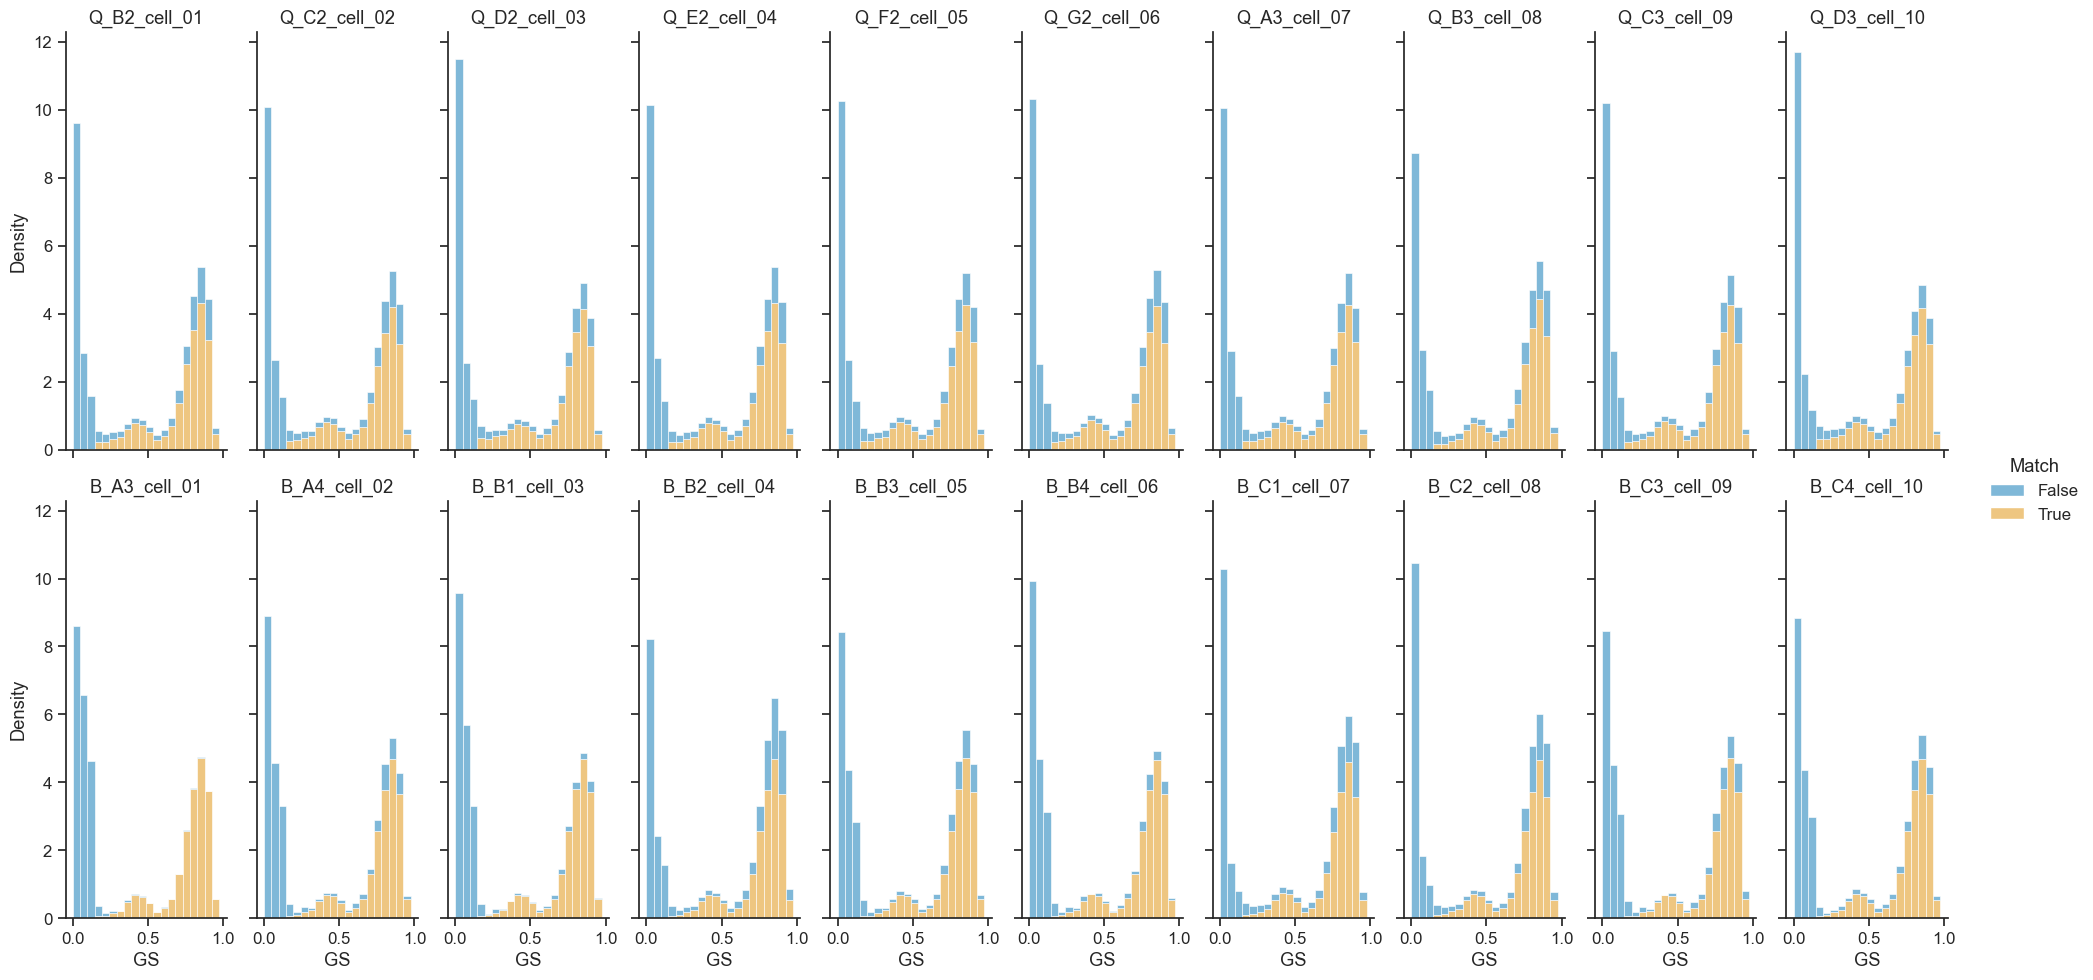

In [280]:
g = sns.displot(vcf, kind="hist", x="GS", hue="Match", col="User ID", col_wrap=10, multiple="stack", bins=20, col_order=hs["User ID"], 
                aspect=0.4, alpha=0.5, common_norm=False, stat="density")
g.set_titles("{col_name}")